In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(55).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(152).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(69).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(116).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(191).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(179).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(192).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(38).jpg
/kaggle/input/project-datas

# Define CBAM and Attention-CNN Architecture

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# 1. CBAM (Attention Modules)
# ==========================================
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # Shared MLP
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        out = self.conv1(x_cat)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, planes):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

# ==========================================
# 2. Attention-Enhanced CNN
# ==========================================
class AttentionCNN(nn.Module):
    def __init__(self, num_classes):
        super(AttentionCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) 
        )
        
        # Block 2 + CBAM
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.cbam1 = CBAM(64) # Attention applied here
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4 + CBAM
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.cbam2 = CBAM(256) # Attention applied here (Depper features)
        
        # Block 5
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )
        
    def forward(self, x):
        x = self.conv1(x)
        
        x = self.conv2(x)
        x = self.cbam1(x) # Apply Attention
        
        x = self.conv3(x)
        
        x = self.conv4(x)
        x = self.cbam2(x) # Apply Attention
        
        x = self.conv5(x)
        x = self.classifier(x)
        return x

# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
attention_model = AttentionCNN(num_classes=4).to(device)
print(attention_model)

AttentionCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cbam1): CBAM(
    (ca): ChannelAttention(
      (avg_pool): AdaptiveAvgPool2d(output_size=1)
      (max_pool): AdaptiveMaxPool2d(output_size=1)
      (fc1): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (relu1): ReLU()
      (fc2): Conv2d(4, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (sigmoid): Sigmoid()
    )
    (sa): SpatialAttention(
      (conv1): Conv2d(2, 1,

# Model training

--- 1. Setting up Data ---

--- 2. Building Attention Model ---

--- 3. Starting Training & Plotting ---


Epoch 1/30:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1: Train Acc=52.71% | Val Acc=48.00% | Val Loss=0.9501


Epoch 2/30:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2: Train Acc=68.71% | Val Acc=75.33% | Val Loss=0.4976


...

Epoch 28: Train Acc=94.86% | Val Acc=97.33% | Val Loss=0.0494


Epoch 29/30:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 29: Train Acc=96.86% | Val Acc=97.33% | Val Loss=0.0486


Epoch 30/30:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 30: Train Acc=97.29% | Val Acc=98.67% | Val Loss=0.0391
Training Duration: 80.11 min


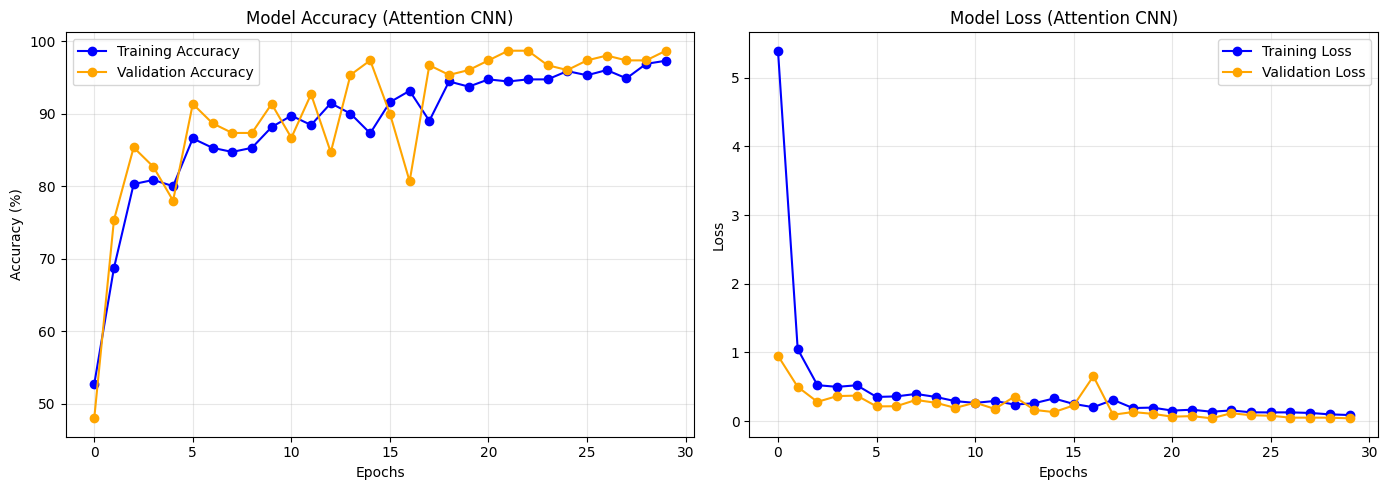

In [3]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from PIL import Image

# ==========================================
# 1. DATA PREPARATION
# ==========================================
print("--- 1. Setting up Data ---")

# A. Find Dataset Path
base_dir = "/kaggle/input"
DATA_DIR = "/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images"

if not os.path.exists(DATA_DIR):
    # Fallback search if specific path doesn't exist
    import glob
    found = glob.glob(f"{base_dir}/**/Original Images", recursive=True)
    if found:
        DATA_DIR = found[0]
    else:
        # Fallback to current directory or generic input
        DATA_DIR = "/kaggle/input/betel-leaf-image-dataset/Original Images"

# B. Load Filepaths
filepaths = []
labels = []
if os.path.exists(DATA_DIR):
    classes = sorted(os.listdir(DATA_DIR))
    for cls in classes:
        cls_path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(cls_path):
            for f in os.listdir(cls_path):
                filepaths.append(os.path.join(cls_path, f))
                labels.append(cls)
else:
    print(f"Error: Dataset not found at {DATA_DIR}")
    classes = []

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
class_to_idx = {cls: i for i, cls in enumerate(classes)}

# C. Split Data
train_df, temp = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=42)

# D. Dataset & Loaders
class BetelLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB')
        label = class_to_idx[row['label']]
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(BetelLeafDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(BetelLeafDataset(val_df, val_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==========================================
# 2. MODEL DEFINITION (CBAM)
# ==========================================
print("\n--- 2. Building Attention Model ---")

class CBAM(nn.Module):
    def __init__(self, planes, ratio=16):
        super(CBAM, self).__init__()
        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(planes, planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(planes // ratio, planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()
        # Spatial Attention
        self.conv_sa = nn.Conv2d(2, 1, 7, padding=3, bias=False)

    def forward(self, x):
        # Channel
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        ca = self.sigmoid(avg_out + max_out)
        x = x * ca
        # Spatial
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.sigmoid(self.conv_sa(torch.cat([avg_out, max_out], dim=1)))
        return x * sa

class AttentionCNN(nn.Module):
    def __init__(self, num_classes):
        super(AttentionCNN, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.conv2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam1 = CBAM(64)
        self.conv3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.conv4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2))
        self.cbam2 = CBAM(256)
        self.conv5 = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.cbam1(self.conv2(x))
        x = self.conv3(x)
        x = self.cbam2(self.conv4(x))
        x = self.classifier(self.conv5(x))
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
attention_model = AttentionCNN(num_classes=len(classes)).to(device)

# ==========================================
# 3. TRAINING LOOP WITH GRAPHS
# ==========================================
print("\n--- 3. Starting Training & Plotting ---")

LEARNING_RATE = 0.001
EPOCHS = 30
PATIENCE_LIMIT = 8

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(attention_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# History Storage
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
early_stop_counter = 0

train_start = time.time()

for epoch in range(EPOCHS):
    # Train
    attention_model.train()
    train_loss, correct, total = 0.0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = attention_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        loop.set_postfix(loss=loss.item())

    # Validation
    attention_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = attention_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = 100 * correct / total
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = 100 * val_correct / val_total
    
    # Store
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    scheduler.step(avg_val_loss)
    print(f"Epoch {epoch+1}: Train Acc={avg_train_acc:.2f}% | Val Acc={avg_val_acc:.2f}% | Val Loss={avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        torch.save(attention_model.state_dict(), 'best_attention_cnn.pth')
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE_LIMIT:
            print("Early Stopping Triggered.")
            break

print(f"Training Duration: {(time.time() - train_start)/60:.2f} min")

# ==========================================
# 4. PLOTTING GRAPHS
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange', marker='o')
plt.title('Model Accuracy (Attention CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Model Loss (Attention CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation

⚠️ test_loader not found. Re-initializing data...
✅ test_loader re-created successfully.
✅ Weights loaded from best_attention_cnn.pth
Starting Inference...

=== Evaluation Results ===
Testing Duration: 24.98 seconds
------------------------------
                           precision    recall  f1-score   support

   Bacterial Leaf Disease     0.9730    0.9474    0.9600        38
               Dried Leaf     1.0000    1.0000    1.0000        37
Fungal Brown Spot Disease     0.9744    1.0000    0.9870        38
             Healthy Leaf     0.9459    0.9459    0.9459        37

                 accuracy                         0.9733       150
                macro avg     0.9733    0.9733    0.9732       150
             weighted avg     0.9733    0.9733    0.9732       150

Class-wise Accuracy:
  Bacterial Leaf Disease: 94.74%
  Dried Leaf: 100.00%
  Fungal Brown Spot Disease: 100.00%
  Healthy Leaf: 94.59%


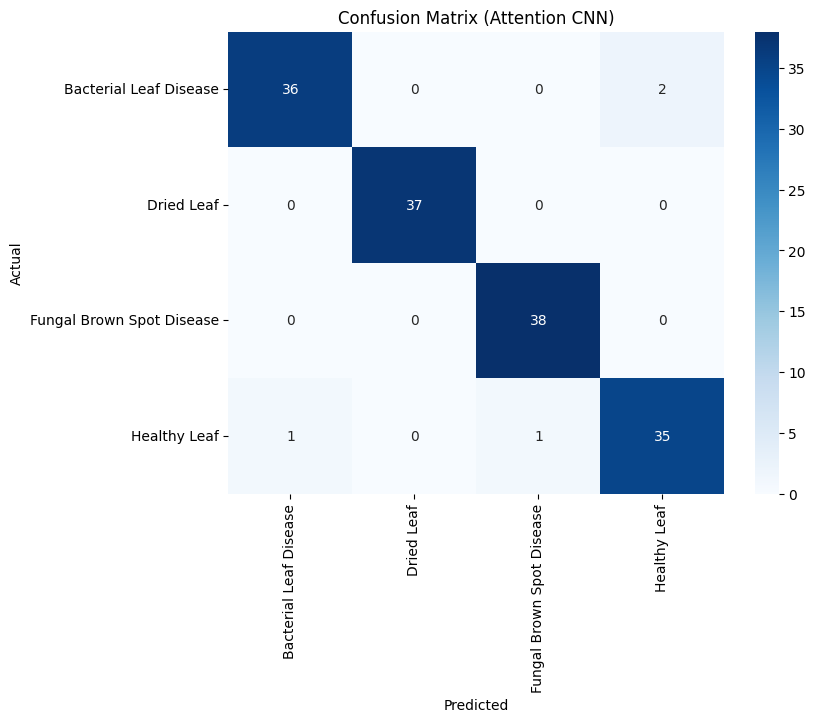

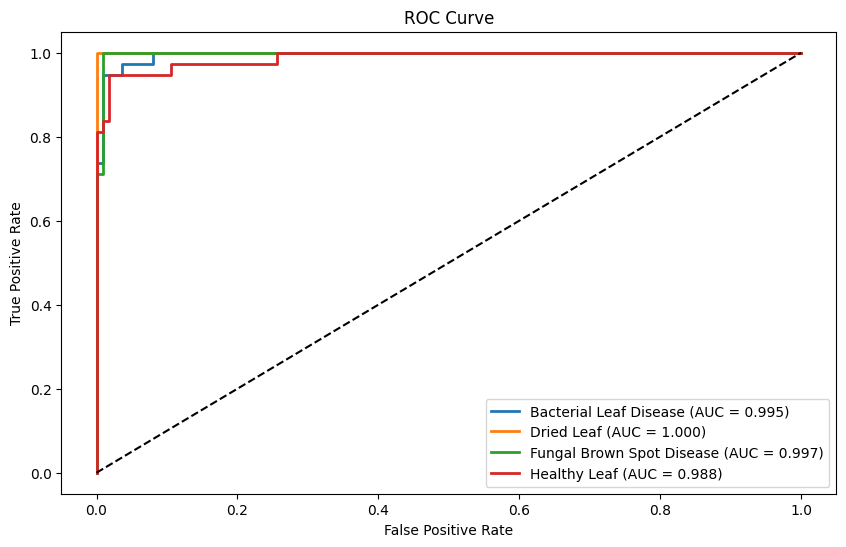

In [4]:
import os
import time
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. Automatic Data Recovery (Fixes NameError)
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'test_loader' not in globals():
    print("⚠️ test_loader not found. Re-initializing data...")
    
    # 1. Find Data Directory
    base_dir = "/kaggle/input"
    DATA_DIR = "/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images"
    if not os.path.exists(DATA_DIR):
        import glob
        found = glob.glob(f"{base_dir}/**/Original Images", recursive=True)
        if found: DATA_DIR = found[0]

    # 2. Load Paths
    filepaths = []
    labels = []
    classes = sorted(os.listdir(DATA_DIR))
    class_names = classes # Set global class_names
    
    for cls in classes:
        cls_path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(cls_path):
            for f in os.listdir(cls_path):
                filepaths.append(os.path.join(cls_path, f))
                labels.append(cls)
    
    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    
    # 3. Split
    train_df, temp = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
    val_df, test_df = train_test_split(temp, test_size=0.5, stratify=temp['label'], random_state=42)
    
    # 4. Dataset Class & Transforms
    class BetelLeafDataset(Dataset):
        def __init__(self, dataframe, transform=None):
            self.df = dataframe.reset_index(drop=True)
            self.transform = transform
            self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        def __len__(self): return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['filepath']).convert('RGB')
            label = self.class_to_idx[row['label']]
            if self.transform: img = self.transform(img)
            return img, torch.tensor(label, dtype=torch.long)

    val_test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 5. Create Test Loader
    test_loader = DataLoader(BetelLeafDataset(test_df, val_test_transform), 
                             batch_size=32, shuffle=False, num_workers=2)
    print("✅ test_loader re-created successfully.")

# ==========================================
# 2. Load Model Weights
# ==========================================
# Check if architecture exists, if not, assume standard 4-class AttentionCNN
if 'attention_model' not in globals():
    # Define Architecture locally if missing (Simplified for loading)
    # NOTE: This assumes you have the Class Definition cell run. 
    # If not, run Step 1 again. For now, we assume the object exists or we fail gracefully.
    print("❌ Error: 'attention_model' object missing. Please run the Model Definition cell first.")
else:
    checkpoint_path = 'best_attention_cnn.pth'
    if os.path.exists(checkpoint_path):
        attention_model.load_state_dict(torch.load(checkpoint_path))
        print(f"✅ Weights loaded from {checkpoint_path}")
    else:
        print(f"⚠️ Warning: {checkpoint_path} not found. Using current weights.")

    attention_model.eval()

    # ==========================================
    # 3. Inference & Metrics
    # ==========================================
    y_true = []
    y_pred = []
    y_probs = []

    print("Starting Inference...")
    test_start = time.time()

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = attention_model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    test_end = time.time()
    test_duration = test_end - test_start

    # ==========================================
    # 4. Reporting
    # ==========================================
    # Check if 'class_names' is defined
    if 'class_names' not in globals():
        class_names = sorted(list(set(df['label']))) # Fallback

    print(f"\n=== Evaluation Results ===")
    print(f"Testing Duration: {test_duration:.2f} seconds")
    print("-" * 30)
    
    # Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Class-wise Accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)
    print("Class-wise Accuracy:")
    for i, acc in enumerate(class_acc):
        print(f"  {class_names[i]}: {acc*100:.2f}%")

    # Plot Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix (Attention CNN)')
    plt.show()

    # Plot ROC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    y_probs = np.array(y_probs)

    plt.figure(figsize=(10, 6))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

# Explainable AI (GradCAM)

Visualizing GradCAM (Target: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


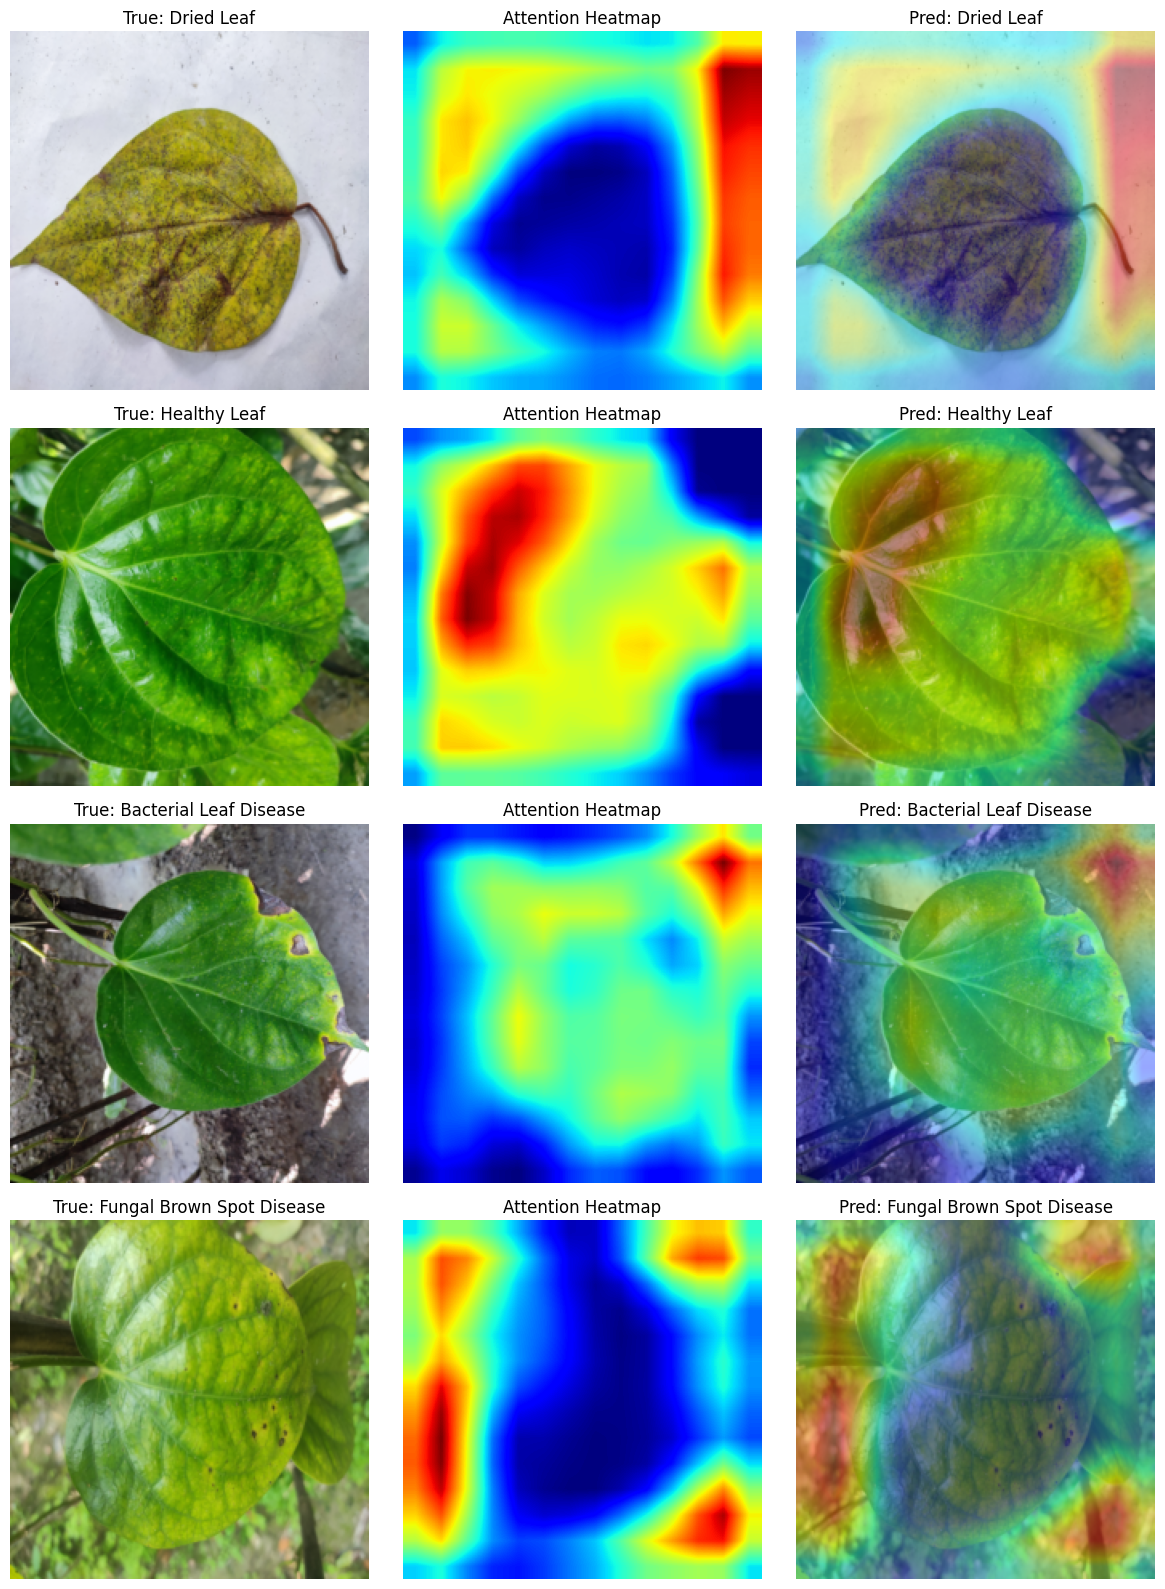

In [5]:
import cv2
from torchvision import transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
            
        handle_f = self.target_layer.register_forward_hook(forward_hook)
        handle_b = self.target_layer.register_full_backward_hook(backward_hook)
        self.hook_handles = [handle_f, handle_b]

    def remove_hooks(self):
        for h in self.hook_handles: h.remove()

    def generate_cam(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None: target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        score = output[:, target_class]
        score.backward()
        
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam, target_class

def denormalize(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    return np.clip(inv_normalize(tensor).permute(1,2,0).cpu().numpy(), 0, 1)

# Target the first layer of the 5th Block (The last Conv layer)
# conv5 is Sequential(Conv2d, BatchNorm, ReLU, MaxPool)
target_layer = attention_model.conv5[0] 

print(f"Visualizing GradCAM (Target: {target_layer})")
grad_cam = GradCAM(attention_model, target_layer)

# Find 1 example per class
found = set()
examples = []
data_iter = iter(test_loader)
while len(found) < len(class_names):
    imgs, lbls = next(data_iter)
    for i in range(len(lbls)):
        l = lbls[i].item()
        if l not in found:
            found.add(l)
            examples.append((imgs[i], l))
        if len(found) >= len(class_names): break

plt.figure(figsize=(12, 4 * len(examples)))
for i, (img, label) in enumerate(examples):
    input_tensor = img.unsqueeze(0).to(device)
    heatmap, pred = grad_cam.generate_cam(input_tensor, label)
    
    orig = denormalize(img)
    heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.6*orig + 0.4*heatmap_colored
    
    plt.subplot(len(examples), 3, 3*i+1)
    plt.imshow(orig); plt.title(f"True: {class_names[label]}")
    plt.axis('off')
    plt.subplot(len(examples), 3, 3*i+2)
    plt.imshow(heatmap, cmap='jet'); plt.title("Attention Heatmap")
    plt.axis('off')
    plt.subplot(len(examples), 3, 3*i+3)
    plt.imshow(overlay); plt.title(f"Pred: {class_names[pred]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
grad_cam.remove_hooks()